# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks V: Inception

<br/>
Jiří Fejlek

2026-02-26
<br/>

The next step in our exploration of various convolutional network architectures brings us to the GoogleLeNet (Inception) [[1](#1)]. Up to this point, every convolutional network followed a straightforward design: it consisted of a single sequence of convolution and pooling layers from the input to the output. *Inception* blocks changed that paradigm and introduced parallel branches of convolutional layers. This means that the features obtained by GoogleLeNet from the input image are no longer extracted using the same convolutions with identical kernel sizes, i.e., the extracted features can vary at different levels of "smudging". 

GoogleLeNet, as the name suggests, was developed by Google in 2014, and it won the ImageNet Large-Scale Visual Recognition Challenge that year. GoogleLeNet was continually improved, and its later iterations are known as Inception-V2 through Inception-V4 (GoogLeNet is also known as Inception-V1).


## Table of Contents

- [GoogLeNet](#googlenet)
    - [Inception Block](#inception-block)
    - [Architecture](#inception-architecture)
    - [Training GoogLenet on Fashion-MNIST](#inception-fashion_mnist)
        - [Image Augmentation and Batch Normalization](#img_aug)
        - [Label Smoothing](#label_smooth)
        - [Adam](#adam)
- [Inception-V2](#inceptionv2)
- [Inception-V3](#inceptionv3)
- [Inception-V4](#inceptionv4)
    - [Inception-V4 on Fashion-MNIST](#inceptionv4-fmnist)
    - [Simplified Inception-V4 for Fashion-MNIST](#inceptionv4-fmnist)
    - [Inception-V4 on CIFAR-10](#inceptionv4-cifar)
- [References](#references)


## GoogLeNet <a class="anchor" id="googlenet"></a>

Let us start with the original incarnation of the Inception convolutional network. First, we define our usual functions used for training the neural networks

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)  

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

### Inception Block <a class="anchor" id="inception-block"></a>

As we mentioned in the introduction, the inception block is a multi-branch block comprising various convolutional (and one pooling) layers. The goal is to extract features from the input at various levels of detail. These features are subsequently concatenated into a single tensor that serves as the block's output [[1](#1)]. 

One design element to note is that the Inception block employs 1x1 convolutions to control the number of channels, as we saw in the last project on Network in Network (NiN).

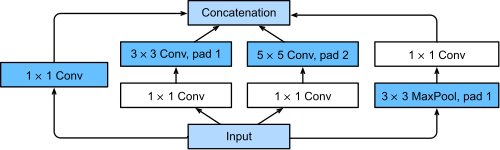

In [6]:
class Inception(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.ReLU())
        
         # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.ReLU())

         # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=5, padding=2), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1), nn.ReLU())
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

### Architecture <a class="anchor" id="inception-architecture"></a>

Let us implement the original GoogLeNet, aka Inception-V1. We should note that, compared to the neural networks that came before, GoogLeNet is very deep (22 layers), and thus vanishing gradients (gradients of earlier layers become extremely small, causing the corresponding weights to stagnate during learning) were a major concern. Hence, GoogLeNet architecture includes auxiliary shallow classifiers inserted into the network during training. The training loss of GoogLeNet is then a sum of the training loss of the whole network and the loss of these 
auxiliary classifiers. Since earlier layers influence auxiliary classifiers' outputs more directly, vanishing gradients should not be as severe. Auxiliary classifiers also aid the regularization [[1](#1)].

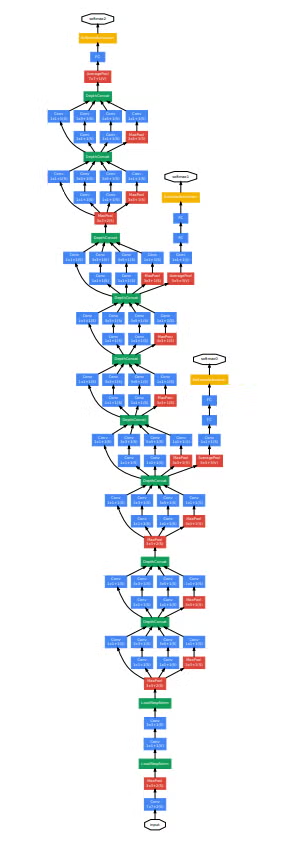

Here, we will use the simplified design without these auxiliary outputs [[2](#2)]. We should note here that we will not encounter auxiliary classifiers in the later designs of neural networks we will discuss in future projects, since there will be alternative remedies for vanishing-gradient problems in very deep neural networks. The first one is batch normalization that we have already employed (chronologically speaking, too early). The second major design element is skip connections in the neural network architecture that we will discuss in the next project, which concerns a residual network: ResNet.

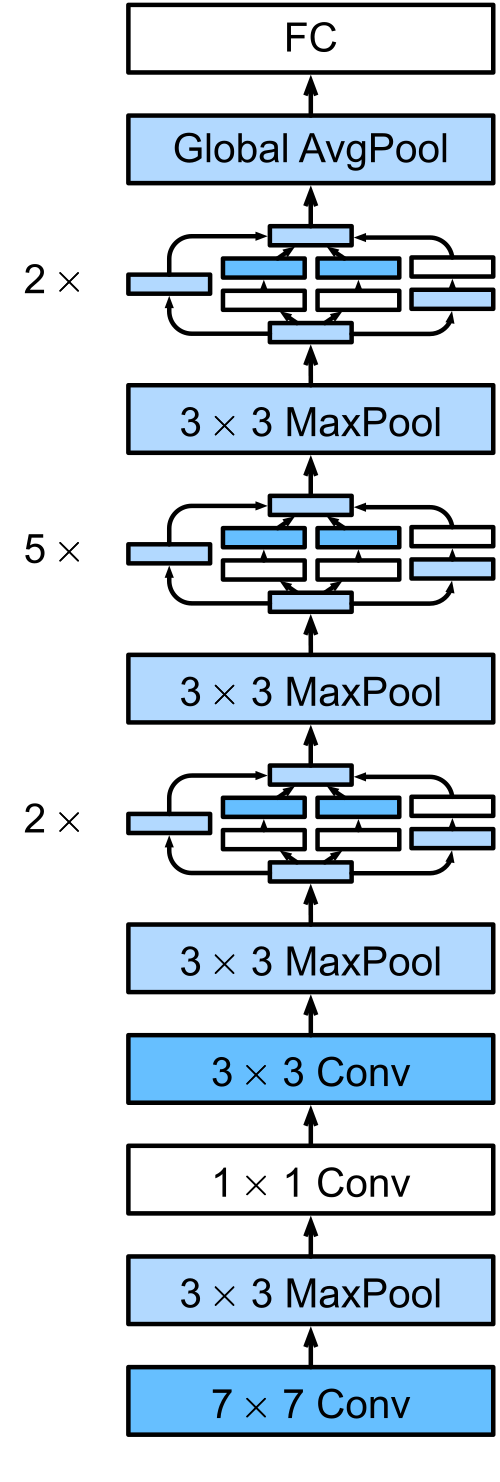!

The architecture of GoogLeNet is summarized in the following table [[1](#1)].

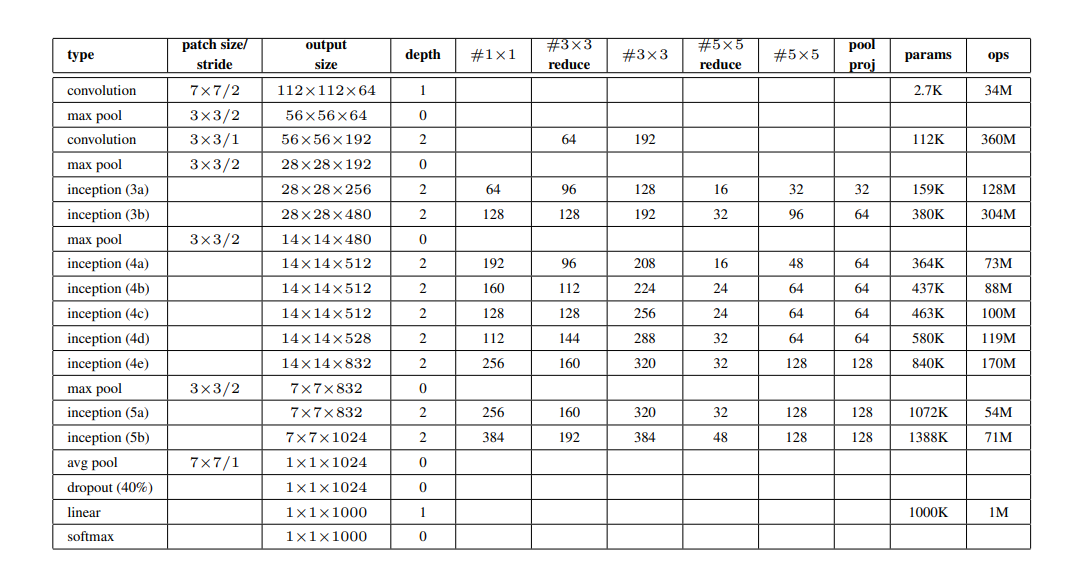

We can also notice that, unlike VGGNet, the classification part uses average pooling and merely one fully connected layer, which significantly reduces the parameter count. 

In [7]:
class GoogLeNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 2
        self.b2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 3
        self.b3 = nn.Sequential(
            Inception(64, (96, 128), (16, 32), 32),
            Inception(128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 4
        self.b4 = nn.Sequential(
            Inception(192, (96, 208), (16, 48), 64),
            Inception(160, (112, 224), (24, 64), 64),
            Inception(128, (128, 256), (24, 64), 64),
            Inception(112, (144, 288), (32, 64), 64),
            Inception(256, (160, 320), (32, 128), 128),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 5
        self.b5 = nn.Sequential(
            Inception(256, (160, 320), (32, 128), 128),
            Inception(384, (192, 384), (48, 128), 128),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten() 
         )

        # stack
        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3, self.b4, self.b5, 
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [8]:
layer_summary(GoogLeNet(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 192, 8, 8])
Sequential output shape:	 torch.Size([1, 480, 4, 4])
Sequential output shape:	 torch.Size([1, 832, 2, 2])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


### Training GoogLenet on Fashion-MNIST <a class="anchor" id="inception-fashion_mnist"></a>

As usual, we will first train GoogLeNet on the Fashion-MNIST dataset [[3](#3)]. We will rescale the images to 64x64 to make the inputs more suitable for GoogLeNet (GoogLeNet is primarily designed for 224x224 ImageNet figures).

In [9]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

# googlenet initialization
GoogleNet_cuda = GoogLeNet(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
GoogleNet_cuda(x);
GoogleNet_cuda.apply(init_weights_he);

The number of parameters of GoogLenet is as follows.

In [10]:
sum(p.numel() for p in GoogleNet_cuda.parameters() if p.requires_grad)

5977530

Despite GoogLeNet being the most complex architecture we have encountered so far, the parameter count of 6 million is quite modest (remember that VGGNet-11 has almost 130 million parameters). This clearly shows how inefficient the simple earlier designs, such as AlexNet and VGGNet, truly were. 

Let us train GoogLeNet.

In [11]:
optim_SGD_cuda =  torch.optim.SGD(GoogleNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, GoogleNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1107.37939119339


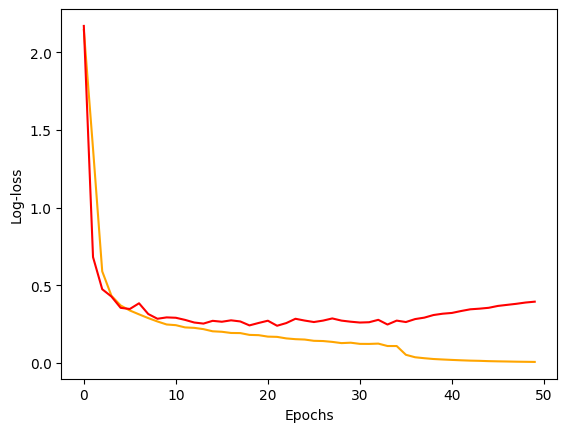

In [12]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

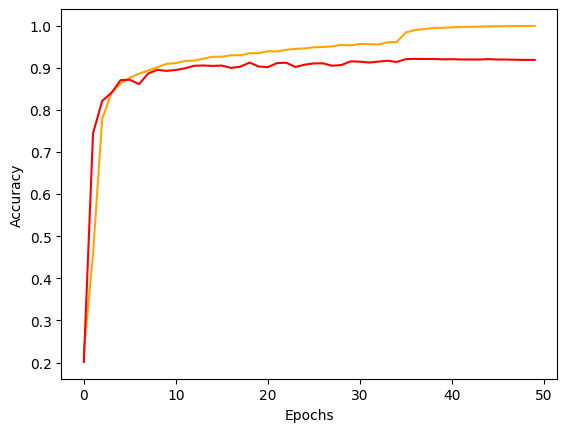

In [13]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

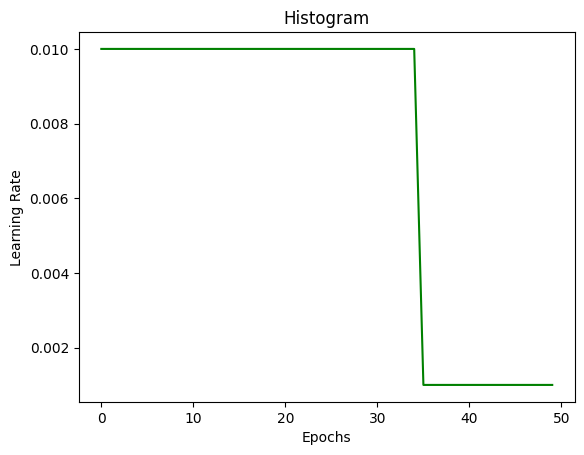

In [14]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [15]:
accu_epochs_train[49]

0.9992833733558655

In [16]:
accu_epochs_test[49]

0.9186999797821045

In [17]:
accu_epochs_test.max()

0.9210000038146973

This accuracy is slightly worse (about 2%) than that obtained from the out-of-the-box VGGNet-11. Next, we employ some tricks, old and new, to improve the performance a bit.

#### Image Augmentation and Batch Normalization<a class="anchor" id="img_aug"></a>

We start with the standard image augmentation and  batch normalization. Batch normalization was actually originally proposed by the designers of GoogLeNet and used in its second version, Inception-V2 [[4](#4)]. 

In [18]:
class Inception_bn(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=5, padding=2), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

In [19]:
class GoogLeNet_bn(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 2
        self.b2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 3
        self.b3 = nn.Sequential(
            Inception_bn(64, (96, 128), (16, 32), 32),
            Inception_bn(128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 4
        self.b4 = nn.Sequential(
            Inception_bn(192, (96, 208), (16, 48), 64),
            Inception_bn(160, (112, 224), (24, 64), 64),
            Inception_bn(128, (128, 256), (24, 64), 64),
            Inception_bn(112, (144, 288), (32, 64), 64),
            Inception_bn(256, (160, 320), (32, 128), 128),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 5
        self.b5 = nn.Sequential(
            Inception_bn(256, (160, 320), (32, 128), 128),
            Inception_bn(384, (192, 384), (48, 128), 128),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten() 
         )

        # stack
        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3, self.b4, self.b5, 
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [20]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

# googlenet initialization
GoogleNet_bn_cuda = GoogLeNet_bn(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
GoogleNet_bn_cuda(x);
GoogleNet_bn_cuda.apply(init_weights_he);

In [21]:
optim_SGD_cuda =  torch.optim.SGD(GoogleNet_bn_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.0)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, GoogleNet_bn_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1882.0000290870667


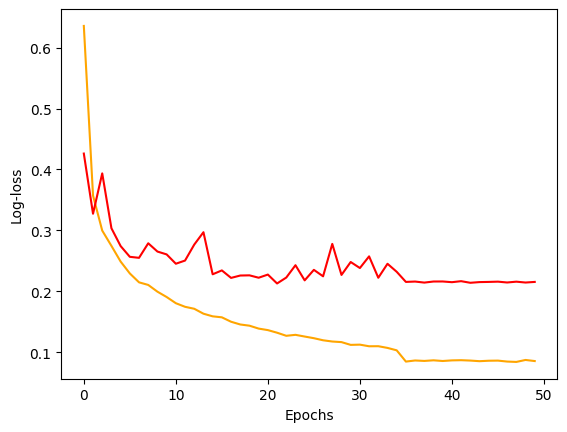

In [22]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

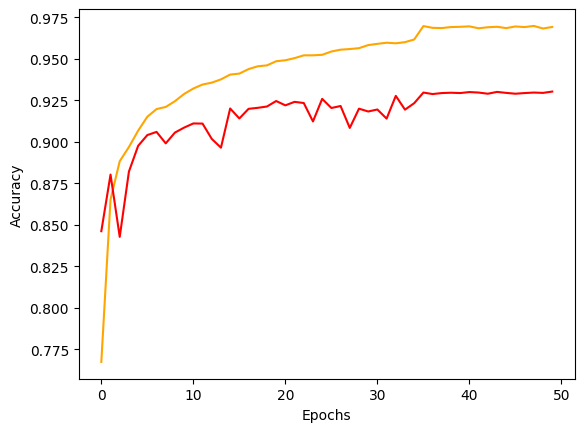

In [23]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

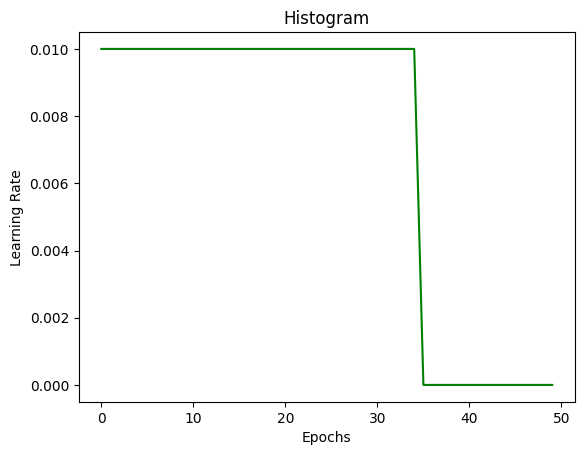

In [24]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [25]:
accu_epochs_train[49]

0.9692167043685913

In [26]:
accu_epochs_test[49]

0.9302999973297119

In [27]:
accu_epochs_test.max()

0.9302999973297119

#### Label Smoothing <a class="anchor" id="label_smooth"></a>

Label smoothing is a regularization technique proposed in the paper that introduced Inception-V3 [[5](#5)]. When training the classifiers, we use the loss based on multinomial log-likelihood, which can also be interpreted as minimizing Kullback-Leibler divergence $\mathrm{KL} (Q||P) = \sum_k q_k \mathrm{log} \frac{q_k}{p_k}$  between the predicted probability distribution of $p$ and the observed probabilities $q$ (which is  $q_{k, i} = 1$ for the $i$-th observation provided that it belongs to $k$-th class) $$ L = - \sum_i \sum_k q_{k, i} \text{log }p_{k, i} = \mathrm{KL}(Q||P) + \text{const}(Q)$$


When using label smoothing, we replace the observed distribution $q$ (which is 0-1) with a mixture of $q$ and the uniform distribution. This encourages the model to converge to predicted probabilities that are less confident and hence, more robust to new data.

In [28]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

# googlenet initialization
GoogleNet_bn_cuda = GoogLeNet_bn(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
GoogleNet_bn_cuda(x);
GoogleNet_bn_cuda.apply(init_weights_he);

In [29]:
optim_SGD_cuda =  torch.optim.SGD(GoogleNet_bn_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, GoogleNet_bn_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1862.9177374839783


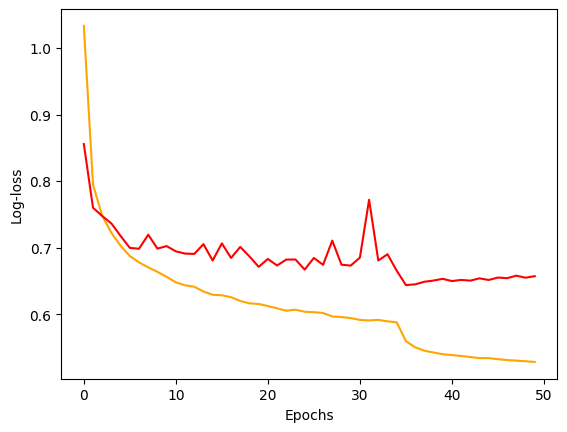

In [30]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

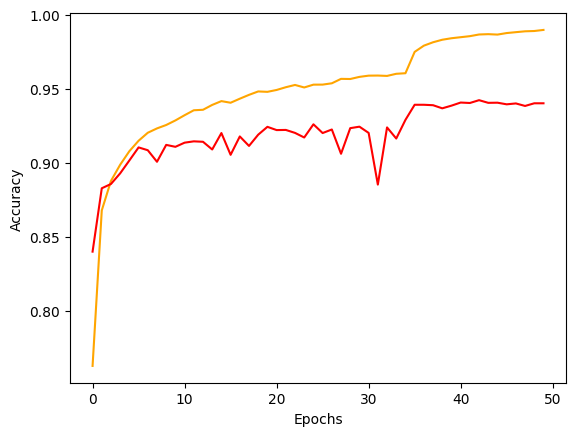

In [31]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

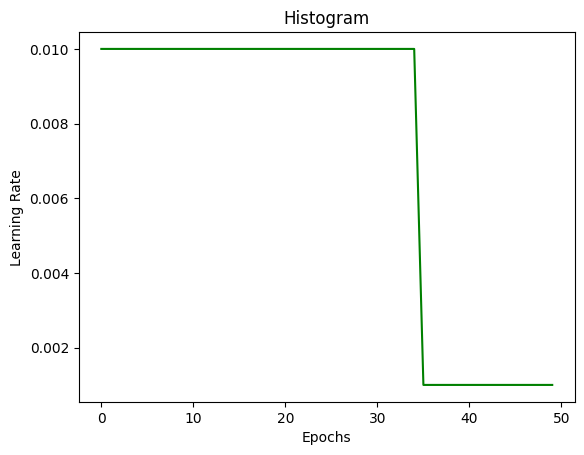

In [32]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [33]:
accu_epochs_train[49]

0.9896500110626221

In [34]:
accu_epochs_test[49]

0.9400999546051025

In [35]:
accu_epochs_test.max()

0.9422000050544739

## Inception-V2 <a class="anchor" id="inceptionv2"></a>

As we have mentioned, the development of GoogLeNet continued, and new updated versions of the Inception convolutional neural network emerged. Inception-V2 [[4](#4)] introduced batch normalization, which has been widely used in convolutional networks ever since. It also used a mix of average and max pooling in the inception blocks, along with a modified inception block for downsampling (GoogLenet used simple max-pooling layers between inception blocks). 

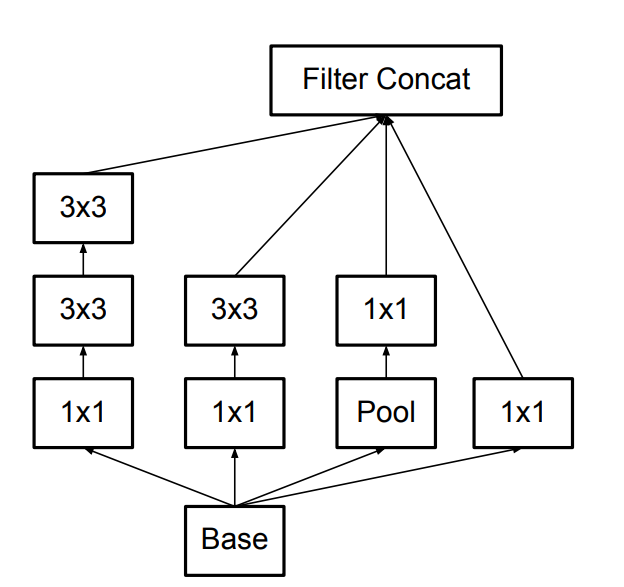

In [36]:
class Inception2_avg(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

In [37]:
class Inception2_max(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

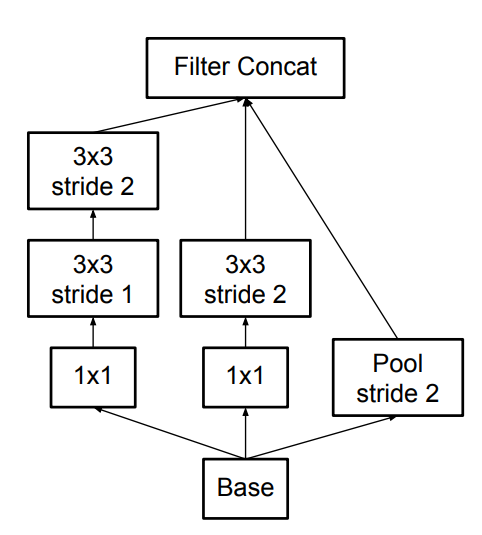

In [38]:
class Inception2_max_pass(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2):
        super().__init__()

      
        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c1[1], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        return torch.cat((branch1, branch2, branch3), dim=1)

The Inception-V2 architecture is in the following table [[4](#4)]. We should note that there is a mistake in the number of channels for channels in the fourth inception block (the numbers do not add up to 576). We modified the number of channels in our implementation to make the total number of channels correct.

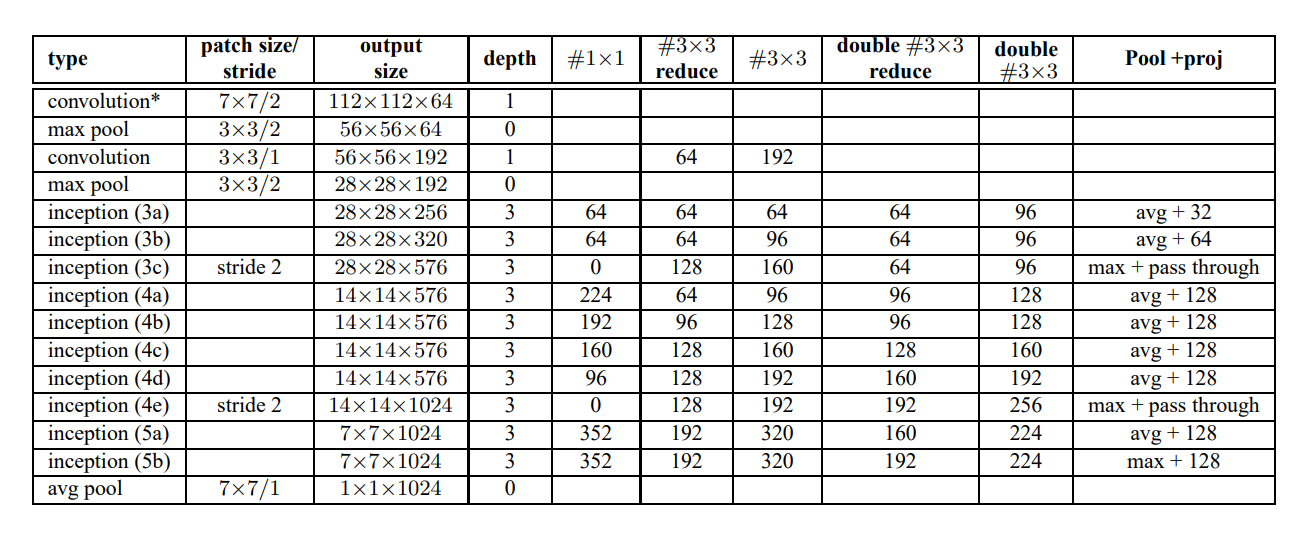

In [39]:
class InceptionV2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 2
        self.b2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block 3
        self.b3 = nn.Sequential(
            Inception2_avg(64, (64, 64), (64, 96), 32),
            Inception2_avg(64, (64, 96), (64, 96), 64),
            Inception2_max_pass((128, 160), (64, 96))
        )

        # block 4
        self.b4 = nn.Sequential(
            Inception2_avg(224, (64, 96), (96, 128), 128),
            Inception2_avg(192, (96, 128), (96, 128), 128),
            Inception2_avg(128, (128, 160), (128, 160), 128),
            Inception2_avg(64, (128, 192), (160, 192), 128),
            Inception2_max_pass((128, 192), (192, 256))
        )

        # block 5
        self.b5 = nn.Sequential(
            Inception2_avg(352, (192, 320), (160, 224), 128),
            Inception2_max(352, (192, 320), (192, 224), 128),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten() 
         )

        # stack
        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3, self.b4, self.b5, 
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [40]:
layer_summary(InceptionV2(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 192, 8, 8])
Sequential output shape:	 torch.Size([1, 576, 4, 4])
Sequential output shape:	 torch.Size([1, 1024, 2, 2])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


Let us train the model.

In [41]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

# inception initialization
InceptionV2_cuda = InceptionV2(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV2_cuda(x);
InceptionV2_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(InceptionV2_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV2_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1955.8432924747467


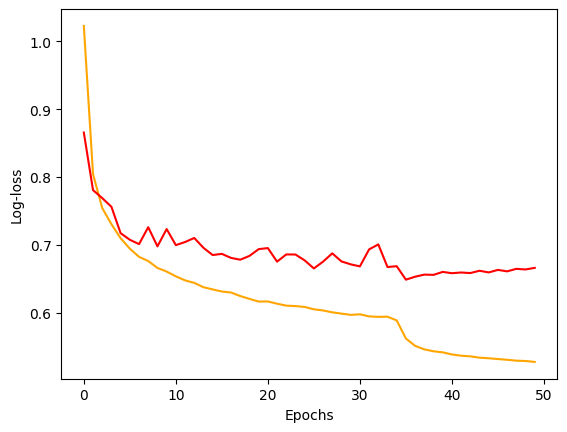

In [42]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

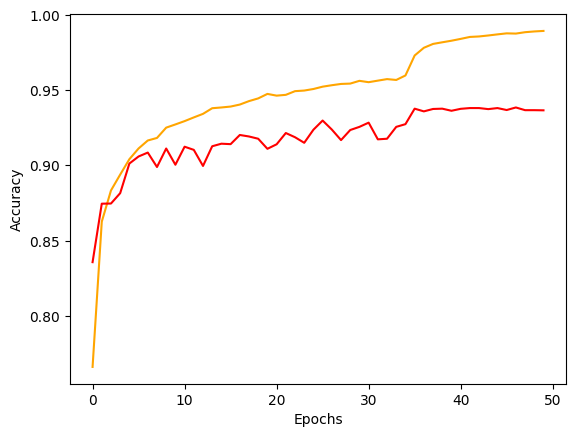

In [43]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

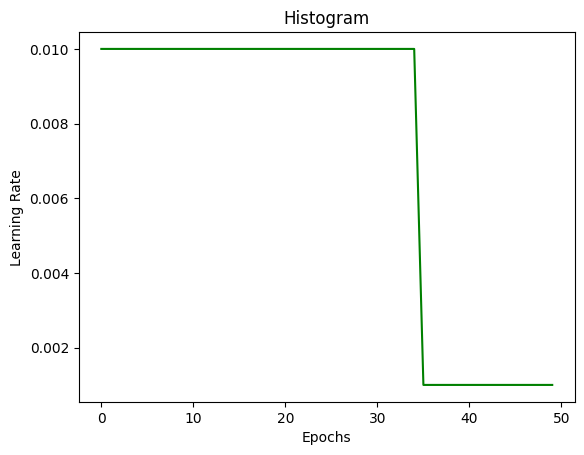

In [44]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [45]:
accu_epochs_train[49]

0.9895166754722595

In [46]:
accu_epochs_test[49]

0.9366999864578247

In [47]:
accu_epochs_test.max()

0.9386000037193298

We have slightly improved the accuracy by about 1%.

## Inception-V3 <a class="anchor" id="inceptionv3"></a>

Inception-V3 is another evolution of the inception architecture [[5](#5)]. It uses new blocks with 1x7, 7x1, 3x1, and 1x3 *factorized* convolutions. The first new block is as follows.

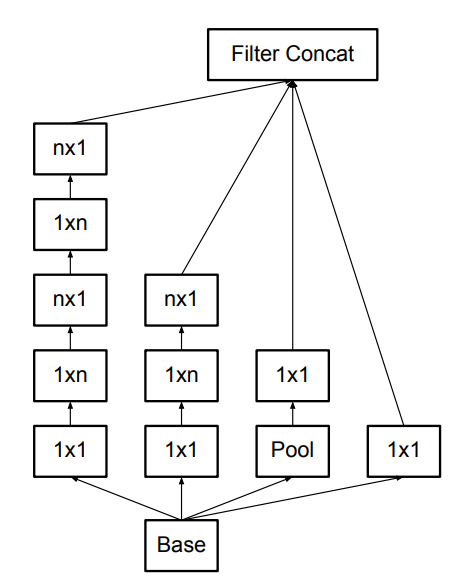

In [48]:
class Inception3_fctr(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(),  nn.ReLU())


        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[0], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[0], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[0], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[0], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1),
                                nn.LazyBatchNorm2d(),
                                nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

This block has an alternative version that downsamples the features with a stride = 2.

In [49]:
class Inception3_fctr_pass(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c1[1], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[0], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[0], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[0], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU()
                               )
        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        return torch.cat((branch1, branch2, branch3), dim=1)

The second new block has the following architecture [[5](#5)]. 

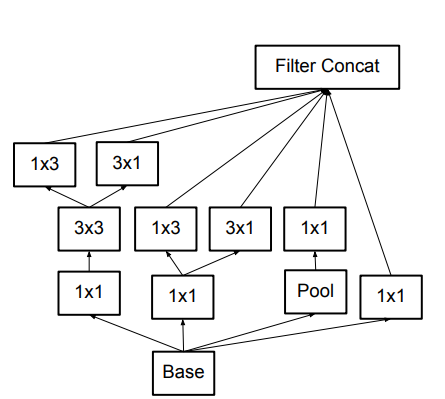

In [50]:
class Inception3_exp(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(),  nn.ReLU())


        # Branch 2
        self.b2_1 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b2_2_1 = nn.Sequential(nn.LazyConv2d(c2[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b2_2_2 = nn.Sequential(nn.LazyConv2d(c2[1], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()) 
 

        # Branch 3
        self.b3_1 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                  nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU()
                                  )
        
        self.b3_2_1 = nn.Sequential(nn.LazyConv2d(c3[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b3_2_2 = nn.Sequential(nn.LazyConv2d(c3[1], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()) 
        

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1),
                                nn.LazyBatchNorm2d(),
                                nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)

        branch2 = self.b2_1(x)
        branch2_1 = self.b2_2_1(x)
        branch2_2 = self.b2_2_2(x)

        branch3 = self.b3_1(x)
        branch3_1 = self.b3_2_1(branch3)
        branch3_2 = self.b3_2_2(branch3)

        branch4 = self.b4(x)
        return torch.cat((branch1, branch2_1, branch2_2, branch3_1, branch3_2, branch4), dim=1)

The last block used in Inception-V3 is the same as in Inception-V2; we already implemented it as *Inception2_avg* and *Inception2_max_pass*.

The full architecture of Inception-V3 is unfortunately not fully described in [[5](#5)], thus we based our number of channels in the inception blocks on the PyTorch implementation (https://docs.pytorch.org/vision/main/models/inception.html).

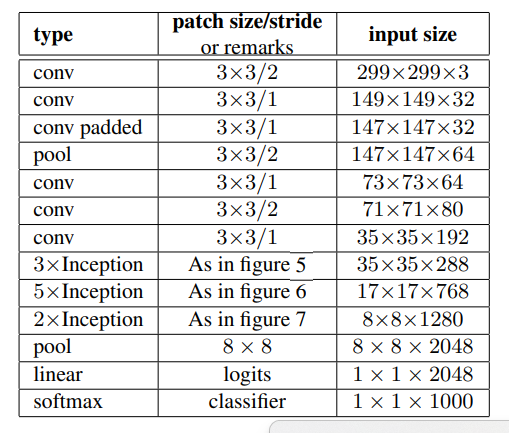

In [51]:
class InceptionV3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(64, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # block 2
        self.b2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(80, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU()
        )

        # block 3
        self.b3 = nn.Sequential(
            Inception2_avg(64, (48, 64), (64, 96), 32),
            Inception2_avg(64, (48, 64), (64, 96), 64),
            Inception2_avg(64, (48, 64), (64, 96), 64),
            Inception2_max_pass((320, 384), (64, 96))
        )

        # block 4
        self.b4 = nn.Sequential(
            Inception3_fctr(192, (128, 192), (128, 192), 192),
            Inception3_fctr(192, (160, 192), (160, 192), 192),
            Inception3_fctr(192, (160, 192), (160, 192), 192),
            Inception3_fctr(192, (192, 192), (192, 192), 192),
            Inception3_fctr_pass((192, 320), (192, 192)),
        )

        # block 5
        self.b5 = nn.Sequential(
            Inception3_exp(320, (384, 384), (448, 384), 192),
            Inception3_exp(320, (384, 384), (448, 384), 192),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten() 
         )

        # stack
        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3, self.b4, self.b5, 
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [52]:
layer_summary(InceptionV3(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 15, 15])
Sequential output shape:	 torch.Size([1, 192, 8, 8])
Sequential output shape:	 torch.Size([1, 768, 4, 4])
Sequential output shape:	 torch.Size([1, 1280, 2, 2])
Sequential output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


In [53]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

# inception initialization
InceptionV3_cuda = InceptionV3(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV3_cuda(x);
InceptionV3_cuda.apply(init_weights_he);

In [54]:
optim_SGD_cuda =  torch.optim.SGD(InceptionV3_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV3_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2123.0918958187103


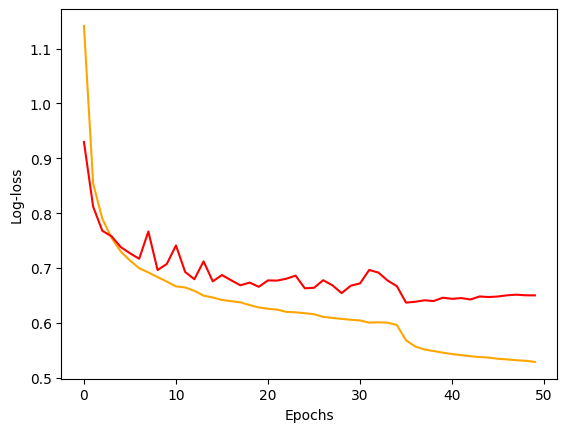

In [55]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

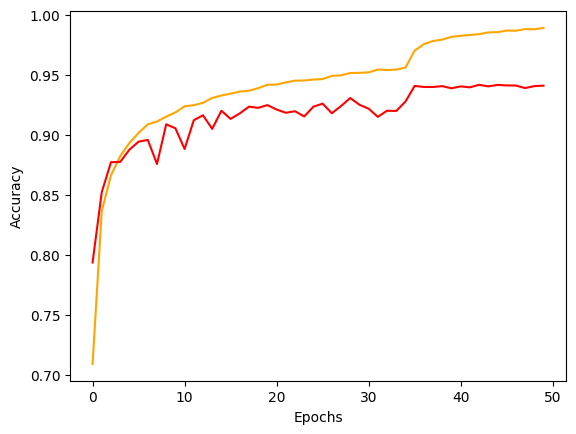

In [56]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

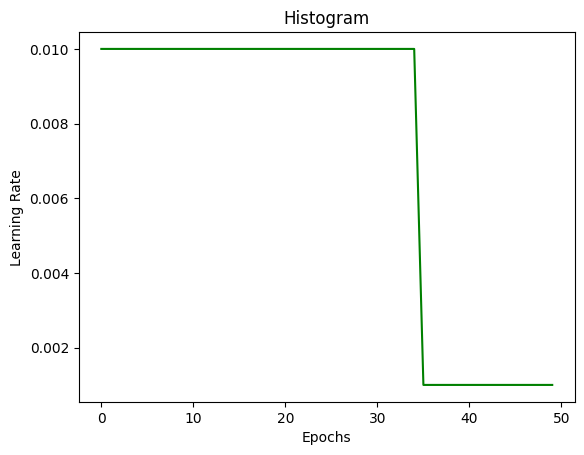

In [57]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [58]:
accu_epochs_train[49]

0.9891166687011719

In [59]:
accu_epochs_test[49]

0.9409999847412109

In [60]:
accu_epochs_test.max()

0.9416999816894531

This performance is very similar to Inception-V2.

## Inception-V4 <a class="anchor" id="inceptionv4"></a>

The inception blocks in Inception-V4 [[11](#11)] are very similar to V3; we already implemented block A as *Inception2_avg*, the number of channels are as follows.

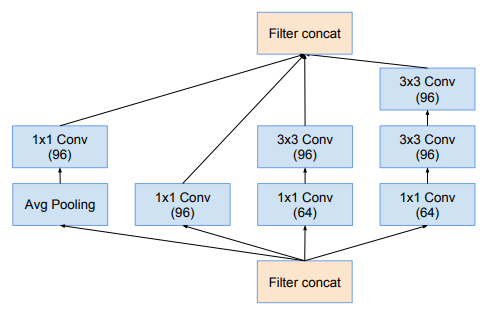

Block B is *Inception3_fctr* in our implementation, but we need more flexible parametrization of the number of channels.

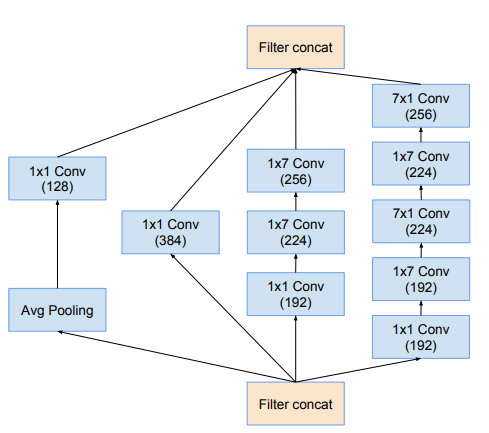

In [61]:
class Inception4_B(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(),  nn.ReLU())


        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[2], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[2], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[3], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[4], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1),
                                nn.LazyBatchNorm2d(),
                                nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

Block C is very similar to *Inception3_exp*, the 3x3 convolution in branch 3 is just factorized into two convolutions 1x3 and 3x1.

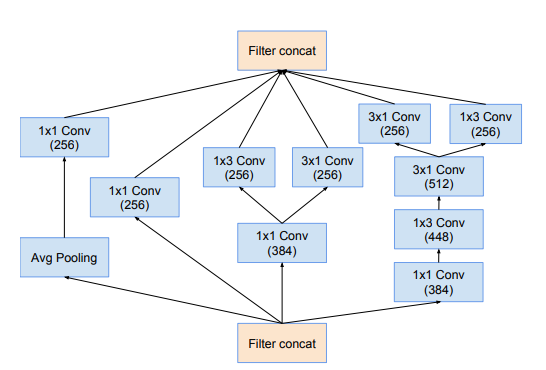

In [62]:
class Inception4_C(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(),  nn.ReLU())


        # Branch 2
        self.b2_1 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b2_2_1 = nn.Sequential(nn.LazyConv2d(c2[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b2_2_2 = nn.Sequential(nn.LazyConv2d(c2[1], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()) 
 

        # Branch 3
        self.b3_1 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                  nn.LazyConv2d(c3[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                  nn.LazyConv2d(c3[2], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()
                                  )
        
        self.b3_2_1 = nn.Sequential(nn.LazyConv2d(c3[3], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU())
        self.b3_2_2 = nn.Sequential(nn.LazyConv2d(c3[3], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU()) 
        

        # Branch 4
        self.b4 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                nn.LazyConv2d(c4, kernel_size=1),
                                nn.LazyBatchNorm2d(),
                                nn.ReLU())      
    def forward(self, x):
        branch1 = self.b1(x)

        branch2 = self.b2_1(x)
        branch2_1 = self.b2_2_1(x)
        branch2_2 = self.b2_2_2(x)

        branch3 = self.b3_1(x)
        branch3_1 = self.b3_2_1(branch3)
        branch3_2 = self.b3_2_2(branch3)

        branch4 = self.b4(x)
        return torch.cat((branch1, branch2_1, branch2_2, branch3_1, branch3_2, branch4), dim=1)

The first reduction module (for downsampling the images) has parameters $k = 192, l = 224, m = 256, n = 384$ (V in the sketch denotes valid padding, i.e., padding = 0; we will always use padding that does not decrease the size of the image in our implementation, since we are dealing with much smaller images).

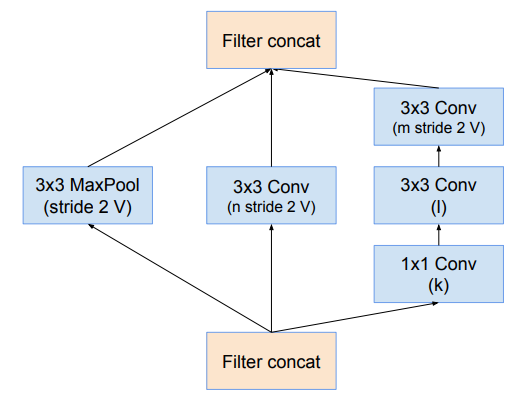

In [63]:
class Inception4_red1(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[2], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)

        
        return torch.cat((branch1, branch2, branch3), dim=1)

The second reduction is structuraly the same as *Inception3_fctr_pass.*

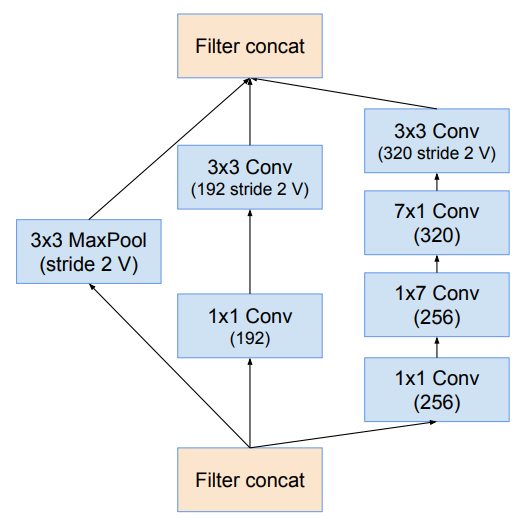

In [64]:
class Inception4_red2(nn.Module):

    def __init__(self, c1, c2):
        super().__init__()


        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c1, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[2], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[3], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU()
                               )

        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        return torch.cat((branch1, branch2, branch3), dim=1)

The biggest difference from V3 is a more complex *stem*.

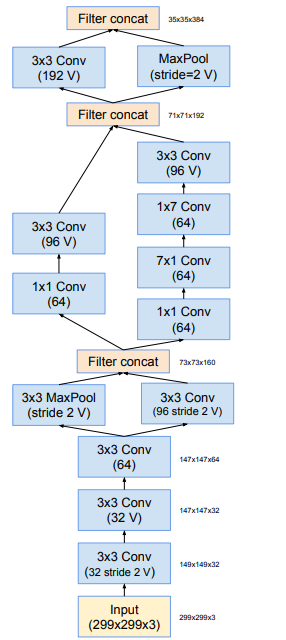 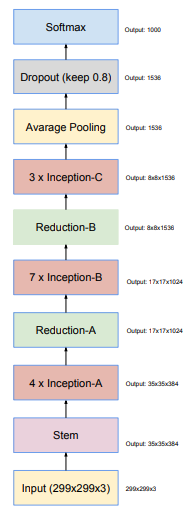

In [65]:
class InceptionV4_stem(nn.Module):
    def __init__(self):
        super().__init__()

        # block 1
        self.sb1 = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),     
        )

        self.sb1_1 = nn.Sequential(nn.LazyConv2d(96, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.sb1_2 =  nn.MaxPool2d(kernel_size=3, stride=2, padding = 1)

        # block 2
        self.sb2_1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1, stride=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(96, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU()
        )

        self.sb2_2 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1, stride=1, padding = 0), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=(7,1), stride=1, padding = (3,0)), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=(1,7), stride=1, padding = (0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(96, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU()
        )

        # block 3
        self.sb3_1 = nn.Sequential(nn.LazyConv2d(192, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.sb3_2 = nn.MaxPool2d(kernel_size=3, stride=2, padding = 1)

    def forward(self, x):
        sblock1 = self.sb1(x)
        sblock1_1 = self.sb1_1(sblock1)
        sblock1_2 = self.sb1_2(sblock1)
        sblock1_result = torch.cat((sblock1_1, sblock1_2), dim=1)

        sblock2_1 = self.sb2_1(sblock1_result)
        sblock2_2 = self.sb2_2(sblock1_result)
        sblock2_result = torch.cat((sblock2_1, sblock2_2), dim=1)

        sblock3_1 = self.sb3_1(sblock2_result)
        sblock3_2 = self.sb3_2(sblock2_result)

        return torch.cat((sblock3_1, sblock3_2), dim=1)

In [66]:
class InceptionV4(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # stem
        self.stem = InceptionV4_stem()

        # body block 1
        self.bblock1 =  nn.Sequential(
            Inception2_avg(96, (64, 96), (64, 96), 96),
            Inception2_avg(96, (64, 96), (64, 96), 96),
            Inception2_avg(96, (64, 96), (64, 96), 96),
            Inception4_red1(384, (192, 224, 256))
        )

        self.bblock2 =  nn.Sequential(
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_B(384, (192, 224, 256), (192, 192, 224, 224, 256), 128),
            Inception4_red2(192, (256, 256, 320, 320))
        )

        self.bblock3 =  nn.Sequential(
            Inception4_C(256, (384,256), (384,448,512,256), 256),
            Inception4_C(256, (384,256), (384,448,512,256), 256),
            Inception4_C(256, (384,256), (384,448,512,256), 256),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
        )
        
        self.net_stack = nn.Sequential(
            self.stem, self.bblock1, self.bblock2, self.bblock3,
            nn.Dropout(0.1),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [67]:
layer_summary(InceptionV4(10),(1, 1, 64, 64))

InceptionV4_stem output shape:	 torch.Size([1, 384, 8, 8])
Sequential output shape:	 torch.Size([1, 1024, 4, 4])
Sequential output shape:	 torch.Size([1, 1536, 2, 2])
Sequential output shape:	 torch.Size([1, 1536])
Dropout output shape:	 torch.Size([1, 1536])
Linear output shape:	 torch.Size([1, 10])


### Inception-V4 on Fashion-MNIST <a class="anchor" id="inceptionv4-fmnist"></a>

In [68]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

# inception initialization
InceptionV4_cuda = InceptionV4(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV4_cuda(x);
InceptionV4_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.SGD(InceptionV4_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, InceptionV4_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2430.159017801285


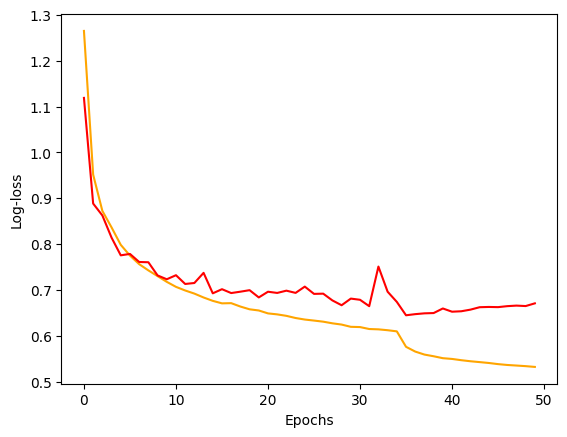

In [69]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

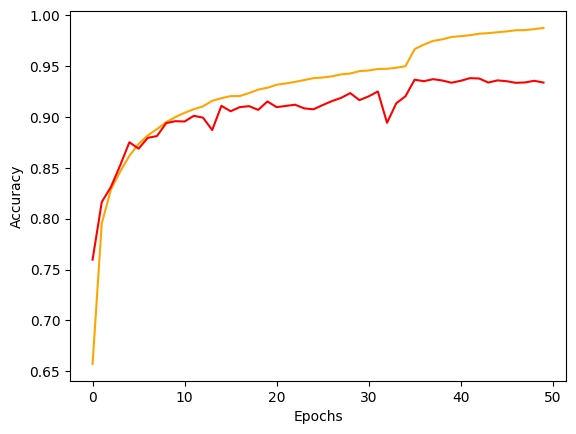

In [70]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

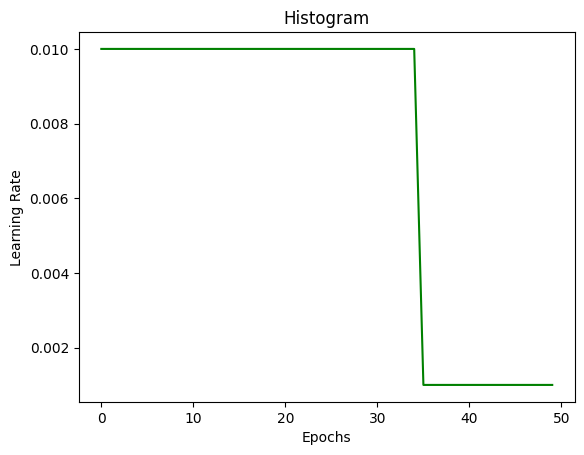

In [71]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [72]:
accu_epochs_train[49]

0.987583339214325

In [73]:
accu_epochs_test[49]

0.933899998664856

In [74]:
accu_epochs_test.max()

0.9381999969482422

This perfromance is actually a bit worse than the one we have obtained from the Inception-V2 and Inception-V3 although we can notice that the perfromance worsened a bit in the last few epochs. Let us now try to reduce the model a bit.

### Simplified Inception-V4 for Fashion-MNIST <a class="anchor" id="sinceptionv4-fmnist"></a>

We will first reduce the stem a bit.

In [75]:
class Inception_stem_red(nn.Module):
    def __init__(self):
        super().__init__()

        self.sb1 = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),     
        )

        self.sb1_1 = nn.Sequential(nn.LazyConv2d(48, kernel_size=3, stride=2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU())
        self.sb1_2 =  nn.MaxPool2d(kernel_size=3, stride=2, padding = 1)


    def forward(self, x):
        sblock1 = self.sb1(x)
        sblock1_1 = self.sb1_1(sblock1)
        sblock1_2 = self.sb1_2(sblock1)
        
        return torch.cat((sblock1_1, sblock1_2), dim=1)

We will also reduce the number of channels in the inception blocks.

In [76]:
class Inception_red(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # stem
        self.stem = Inception_stem_red()

        # body block 1
        self.bblock1 =  nn.Sequential(
            Inception2_avg(48, (64, 48), (32, 48), 48),
            Inception2_avg(48, (64, 48), (32, 48), 48),
            Inception4_red1(192, (96, 112, 128))
        )

        self.bblock2 =  nn.Sequential(
            Inception4_B(192, (96, 112, 128), (96, 96, 112, 112, 128), 64),
            Inception4_B(192, (96, 112, 128), (96, 96, 112, 112, 128), 64),
            Inception4_B(192, (96, 112, 128), (96, 96, 112, 112, 128), 64),
            Inception4_B(192, (96, 112, 128), (96, 96, 112, 112, 128), 64),
            Inception4_red2(96, (128, 128, 160, 160))
        )

        self.bblock3 =  nn.Sequential(
            Inception4_C(128, (192,128), (192,224,256,128), 128),
            Inception4_C(128, (192,128), (192,224,256,128), 128),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
        )
        
        self.net_stack = nn.Sequential(
            self.stem, self.bblock1, self.bblock2, self.bblock3,
            nn.Dropout(0.1),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [77]:
layer_summary(Inception_red(10),(1, 1, 32, 32))

Inception_stem_red output shape:	 torch.Size([1, 80, 16, 16])
Sequential output shape:	 torch.Size([1, 512, 8, 8])
Sequential output shape:	 torch.Size([1, 768, 4, 4])
Sequential output shape:	 torch.Size([1, 768])
Dropout output shape:	 torch.Size([1, 768])
Linear output shape:	 torch.Size([1, 10])


In [78]:
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# inception initialization
Inception_red_cuda = Inception_red(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_red_cuda(x);
Inception_red_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(Inception_red_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, Inception_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)


1919.3283438682556


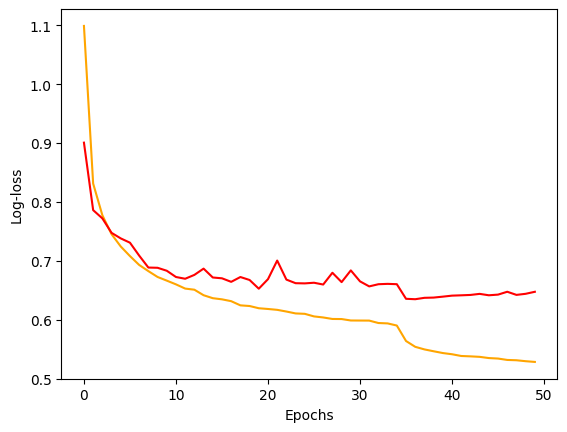

In [79]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

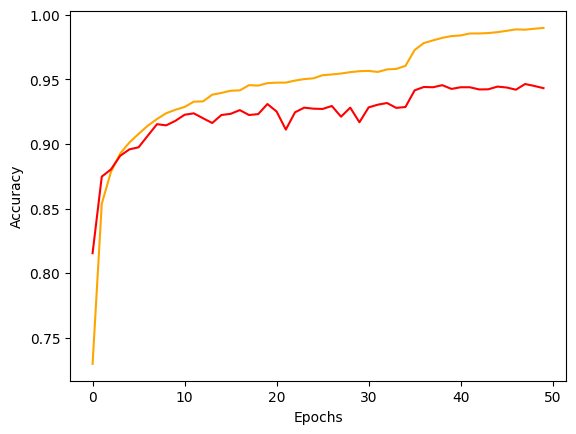

In [80]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

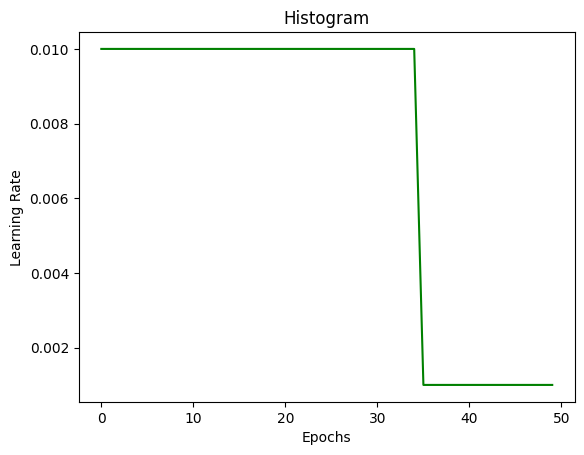

In [81]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [82]:
accu_epochs_train[49]

0.9898333549499512

In [83]:
accu_epochs_test[49]

0.9431999921798706

In [84]:
accu_epochs_test.max()

0.946399986743927

This performance is more in line with our previous Inception models and the attained maximum is actually beest so far in this project.

### Inception-V4 on CIFAR-10 <a class="anchor" id="inceptionv4-cifar"></a>

To conclude this project, we will train the Inception-V4 model on the CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html). We will use the image augmentation and label smoothing right away.

In [85]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[64,64], scale = [0.8,1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.Resize([64,64])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)


# inception initialization
InceptionV4_cuda = InceptionV4(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
InceptionV4_cuda(x);
InceptionV4_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(InceptionV4_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, InceptionV4_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

4565.72176027298


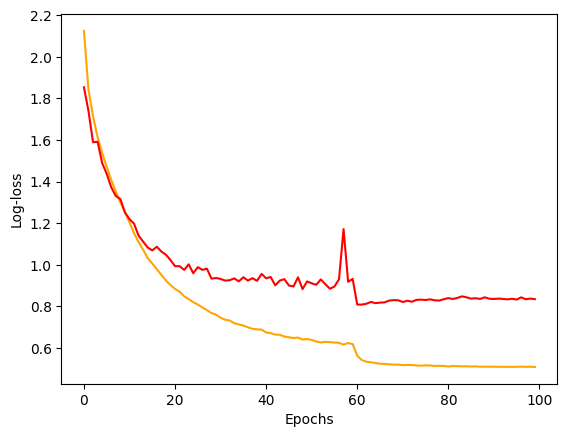

In [86]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

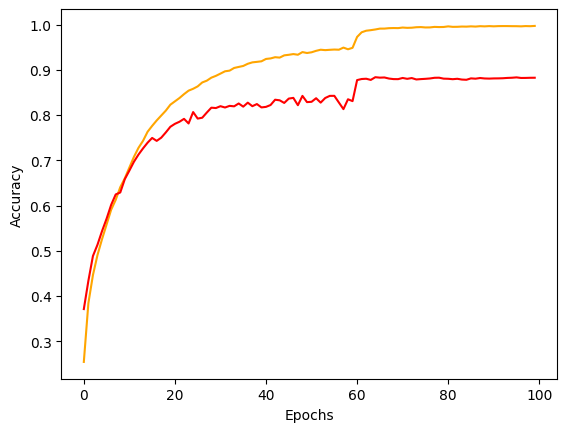

In [87]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

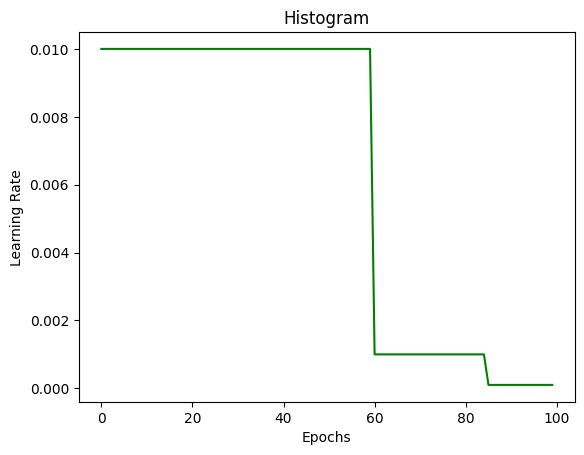

In [88]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [89]:
accu_epochs_train[99]

0.9971799850463867

In [90]:
accu_epochs_test[99]

0.882599949836731

In [91]:
accu_epochs_test.max()

0.8837999701499939

The accuracy of 88% is noticeably worse than the performance we have obtained from VGGNet and the All Convolutional Net. Let us try our reduced version next. 

In [92]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8,1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# inception initialization
Inception_red_cuda = Inception_red(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_red_cuda(x);
Inception_red_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.SGD(Inception_red_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, Inception_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3492.428964614868


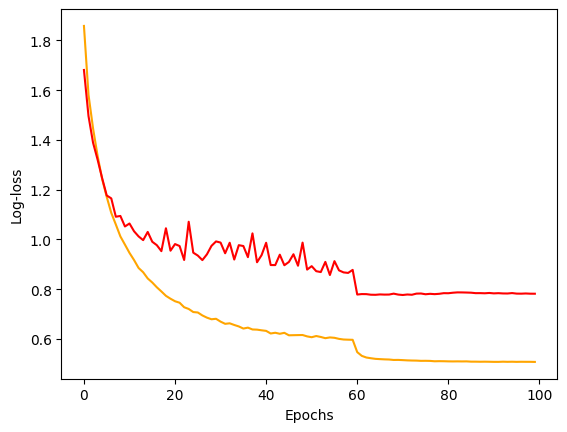

In [93]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

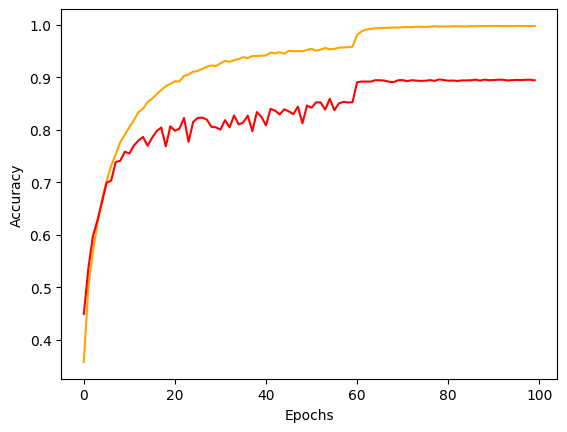

In [94]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

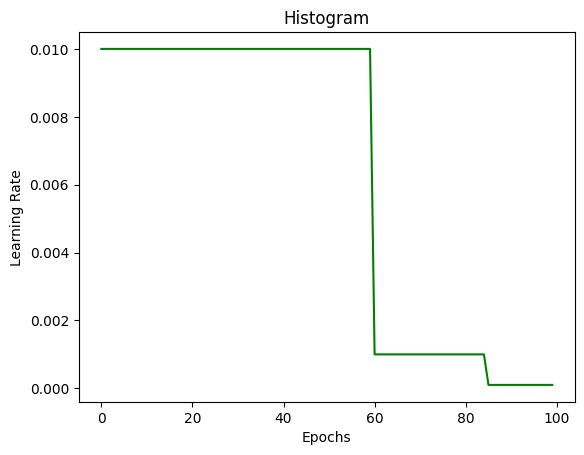

In [95]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [96]:
accu_epochs_train[99]

0.998259961605072

In [97]:
accu_epochs_test[99]

0.894599974155426

In [98]:
accu_epochs_test.max()

0.8962000012397766

The performance got closer to 90%. Still, we would probably have had to experiment with this architecture and the training hyperparameters a bit more to achieve better performance. 

This is a bit of an issue with Inception architecture in general; it is a complex design that is not straightforward to play with. In the next small project, we will take a look at the ResNet architecture from 2015, a quite simple yet revolutionary convolutional neural network that changed the design of all convolutional networks going forward. 

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> SZEGEDY, Christian, et al. Going deeper with convolutions. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2015. p. 1-9.

<a id="2">[2]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="3">[3]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.

<a id="4">[4]</a> IOFFE, Sergey; SZEGEDY, Christian. Batch normalization: Accelerating deep network training by reducing internal covariate shift. In: *International conference on machine learning.* pmlr, 2015. p. 448-456.

<a id="5">[5]</a> SZEGEDY, Christian, et al. Rethinking the inception architecture for computer vision. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2016. p. 2818-2826.

<a id="6">[6]</a> KINGMA, Diederik P.; BA, Jimmy. Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980, 2014.

<a id="7">[7]</a> KESKAR, Nitish Shirish; SOCHER, Richard. Improving generalization performance by switching from adam to sgd. arXiv preprint arXiv:1712.07628, 2017.

<a id="8">[8]</a> ZHOU, Pan, et al. Towards theoretically understanding why sgd generalizes better than adam in deep learning. Advances in Neural Information Processing Systems, 2020, 33: 21285-21296.

<a id="9">[9]</a> ZOU, Difan, et al. Understanding the generalization of adam in learning neural networks with proper regularization. arXiv preprint arXiv:2108.11371, 2021.

<a id="10">[10]</a> PAN, Yan; LI, Yuanzhi. Toward understanding why adam converges faster than sgd for transformers. arXiv preprint arXiv:2306.00204, 2023.

<a id="11">[11]</a> SZEGEDY, Christian, et al. Inception-v4, inception-resnet and the impact of residual connections on learning. In: *Proceedings of the AAAI conference on artificial intelligence.* 2017.